# Modeling

In [62]:
# basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import os

# model selection imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score, make_scorer, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# import warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [49]:
def print_metric_scores(grid, metric):
    cv_results = grid.cv_results_
    best_index = grid.best_index_
    mean_score = cv_results[f"mean_test_{metric}"][best_index]
    std_score = cv_results[f"std_test_{metric}"][best_index]
    print(f"CV {metric} (mean ± std): {mean_score:.3f} ± {std_score:.3f}")

In [9]:
df = pd.read_csv("../data/interim/clean_data.csv")

In [10]:
# fix leakage issues from some engineered features + target variable
leakage_features = [
    'ALL_AIRBAGS_DEPLOYED',     # target variable
    'AIRBAGS_DEPLOYED_COUNT',   # directly counts deployments
    'DEPLOYMENT_RATE',          # 0/1 variable
    'MAX_EJECTION',             # outcome
    'MAX_INJURY_SEV',           # outcome   
    'NUM_INJ',                  # outcome
    'CASENUM',                  # unique key
    'VEH_NO',                   # just an ID
    'MINUTE', 'HOUR', 
    'DAY_WEEK', 'MONTH'
]

In [11]:
# features matrix
X = df.drop(leakage_features, axis=1).select_dtypes(include=np.number)

# target variable
y = df['ALL_AIRBAGS_DEPLOYED']

In [12]:
# split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

In [13]:
scaler = StandardScaler()

# fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# scale test data
X_test_scaled = scaler.transform(X_test)

In [45]:
# weights for helping with imbalance
weights_list = [
    {0: 1, 1: 1},
    {0: 1, 1: 2},
    "balanced",
]

# define scoring metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(fbeta_score, beta=1),
}

## Logistic Regression Model

In [ ]:
# define pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

# define parameter grid
logistic_param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs'],
    'clf__max_iter': [5000],
    "clf__class_weight": weights_list,
}

# setup grid search
logistic_grid = GridSearchCV(
    pipeline,
    logistic_param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
)

# fit model specified by grid search
logistic_grid.fit(X_train, y_train)

# print the best parameters and cross-validation metrics
print("")
print(f"Best parameters found with cross-validation:")
pprint(logistic_grid.best_params_)
print("")
print_metric_scores(logistic_grid, "accuracy")
print_metric_scores(logistic_grid, "precision")
print_metric_scores(logistic_grid, "recall")
print_metric_scores(logistic_grid, "f1")

# make predictions on the test set using the best model
y_pred = logistic_grid.predict(X_test)

# calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = fbeta_score(y_test, y_pred, beta=1)

# print test metrics
print("")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")


Best parameters found with cross-validation:
{'clf__C': 0.1,
 'clf__class_weight': {0: 1, 1: 2},
 'clf__max_iter': 5000,
 'clf__penalty': 'l2',
 'clf__solver': 'lbfgs'}

CV accuracy (mean ± std): 0.844 ± 0.002
CV precision (mean ± std): 0.595 ± 0.007
CV recall (mean ± std): 0.548 ± 0.018
CV f1 (mean ± std): 0.571 ± 0.011

Test Accuracy: 0.8506992048258842
Test Precision: 0.6053268765133172
Test Recall: 0.5555555555555556
Test F1 Score: 0.5793742757821553


## Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)

# define parameter grid
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "class_weight": weights_list,
}

# setup grid search
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
)

# fit model specified by grid search
rf_grid.fit(X_train, y_train)

# print the best parameters and cross-validation metrics
print("")
print(f"Best parameters found with cross-validation:")
pprint(rf_grid.best_params_)
print("")
print_metric_scores(rf_grid, "accuracy")
print_metric_scores(rf_grid, "precision")
print_metric_scores(rf_grid, "recall")
print_metric_scores(rf_grid, "f1")

# make predictions on the test set using the best model
y_pred = rf_grid.predict(X_test)

# calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = fbeta_score(y_test, y_pred, beta=1)

# print test metrics
print("")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")


Best parameters found with cross-validation:
{'class_weight': {0: 1, 1: 2}, 'max_depth': 10, 'n_estimators': 100}

CV accuracy (mean ± std): 0.863 ± 0.002
CV precision (mean ± std): 0.634 ± 0.004
CV recall (mean ± std): 0.647 ± 0.015
CV f1 (mean ± std): 0.640 ± 0.008

Test Accuracy: 0.8697559638058678
Test Precision: 0.6464128843338214
Test Recall: 0.654074074074074
Test F1 Score: 0.6502209131075111


## XGBoost Model

In [51]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
imbalance_ratio = neg / pos

In [63]:
xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [1, imbalance_ratio, imbalance_ratio * 1.5],
}

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
)

xgb_grid.fit(X_train, y_train)

# print the best parameters and cross-validation metrics
print("")
print(f"Best parameters found with cross-validation:")
pprint(rf_grid.best_params_)
print("")
print_metric_scores(xgb_grid, "accuracy")
print_metric_scores(xgb_grid, "precision")
print_metric_scores(xgb_grid, "recall")
print_metric_scores(xgb_grid, "f1")

# make predictions on the test set using the best model
y_pred = xgb_grid.predict(X_test)

# calculate test metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = fbeta_score(y_test, y_pred, beta=1)

# print test metrics
print("")
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")


Best parameters found with cross-validation:
{'class_weight': {0: 1, 1: 2}, 'max_depth': 10, 'n_estimators': 100}

CV accuracy (mean ± std): 0.841 ± 0.002
CV precision (mean ± std): 0.556 ± 0.006
CV recall (mean ± std): 0.776 ± 0.007
CV f1 (mean ± std): 0.648 ± 0.001

Test Accuracy: 0.8474088291746641
Test Precision: 0.5628647214854111
Test Recall: 0.7859259259259259
Test F1 Score: 0.6559505409582689


### Feature Importance

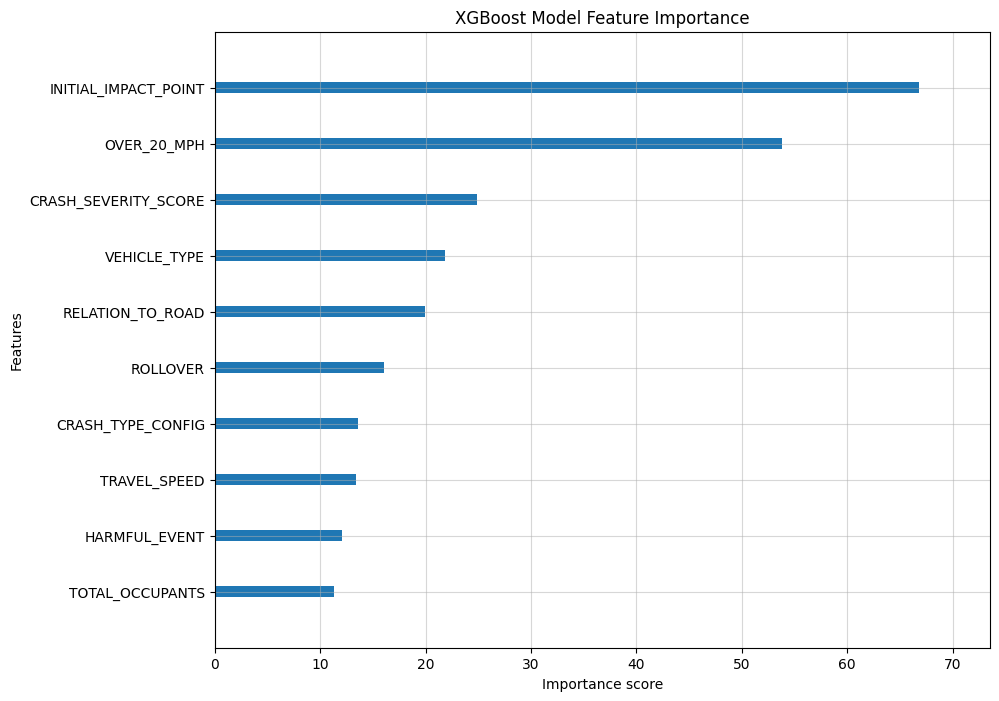

In [ ]:
best_model = xgb_grid.best_estimator_
y_pred_xgb_grid = best_model.predict(X_test)
y_pred_proba_xgb_grid = best_model.predict_proba(X_test)[:, 1] 

fig, ax = plt.subplots(figsize=(10, 8)) 
xgb.plot_importance(best_model, importance_type="gain", max_num_features=10, ax=ax, show_values=False)
plt.title("XGBoost Model Feature Importance")

# rename features to be more understandable
detailed_feature_names = [
    'TOTAL_OCCUPANTS', 'HARMFUL_EVENT', 'TRAVEL_SPEED',
    'CRASH_TYPE_CONFIG', 'ROLLOVER', 'RELATION_TO_ROAD',
    'VEHICLE_TYPE', 'CRASH_SEVERITY_SCORE', 'OVER_20_MPH',
    'INITIAL_IMPACT_POINT'
]

ax.set_yticklabels(detailed_feature_names)
plt.tight_layout()
plt.grid(alpha=0.5)

# save plot
folder_name = "../reports/"
file_name = "xgb_feature_importance_barh.png"
file_path = os.path.join(folder_name, file_name)

plt.savefig(file_path)
plt.show()

## Precision-Recall Plots

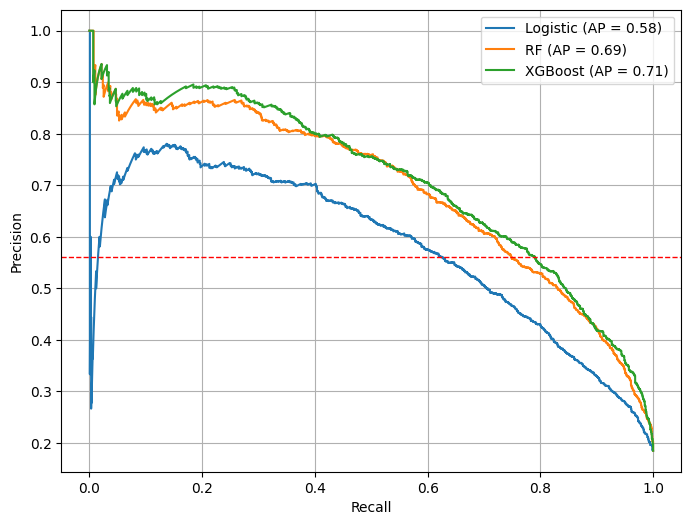

In [69]:
logistic_model = logistic_grid.best_estimator_
rf_model = rf_grid.best_estimator_
xgb_model = xgb_grid.best_estimator_

y_score_log = logistic_model.predict_proba(X_test)[:, 1]
y_score_rf = rf_model.predict_proba(X_test)[:, 1]
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]

precision_log, recall_log, _ = precision_recall_curve(y_test, y_score_log)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_score_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_score_xgb)

ap_log = average_precision_score(y_test, y_score_log)
ap_rf = average_precision_score(y_test, y_score_rf)
ap_xgb = average_precision_score(y_test, y_score_xgb)

plt.figure(figsize=(8, 6))

plt.plot(recall_log, precision_log, label=f"Logistic (AP = {ap_log:.2f})")
plt.plot(recall_rf, precision_rf, label=f"RF (AP = {ap_rf:.2f})")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP = {ap_xgb:.2f})")
plt.axhline(0.56, linestyle='--', color="red", lw=1)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


## Save Predictions for XGBoost

In [70]:
# create new df with all original features
analysis_df = df.loc[X_test.index].copy()

# add predicted probabilities 
analysis_df['predicted_target'] = y_pred_xgb_grid
analysis_df['predicted_probability'] = y_pred_proba_xgb_grid
analysis_df['actual'] = y_test.values

# save df for future analysis
folder_name = "../data/final/"
file_name = "xgb_model_data.csv"
file_path = os.path.join(folder_name, file_name)

analysis_df.to_csv(file_path, index=False)